In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

# Milestone 1: Curve and Swap Analytics

This notebook walks through the core building blocks for Milestone 1:

1. Build simplified market quotes
2. Bootstrap zero-curve nodes
3. Interpolate a daily zero curve
4. Compute annuity and par swap rate
5. Value fixed and floating swap legs
6. Compare payer and receiver swap values

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from swaption_pricing.curve_bootstrap import bootstrap_zero_curve
from swaption_pricing.market_data import build_daily_zero_curve
from swaption_pricing.swap import (
    fixed_leg_pv,
    floating_leg_pv,
    forward_swap_rate,
    swap_annuity,
    swap_present_value,
)
from swaption_pricing.types import MarketQuote

## 1. Build Simplified Market Quotes

For Milestone 1, we use one deposit quote and a sequence of annual-pay par swap quotes. This is not yet a production curve-construction setup, but it is enough to demonstrate the bootstrapping logic clearly.

In [5]:
quotes = [
    MarketQuote(instrument_type='deposit', maturity=1.0, rate=0.0420),
    MarketQuote(instrument_type='swap', maturity=2.0, rate=0.0415, pay_frequency=1),
    MarketQuote(instrument_type='swap', maturity=3.0, rate=0.0410, pay_frequency=1),
    MarketQuote(instrument_type='swap', maturity=4.0, rate=0.0408, pay_frequency=1),
    MarketQuote(instrument_type='swap', maturity=5.0, rate=0.0405, pay_frequency=1),
    MarketQuote(instrument_type='swap', maturity=6.0, rate=0.0403, pay_frequency=1),
    MarketQuote(instrument_type='swap', maturity=7.0, rate=0.0402, pay_frequency=1),
]

pd.DataFrame([quote.__dict__ for quote in quotes])

,instrument_type,maturity,rate,pay_frequency
0,deposit,1.0,0.0420,1
1,swap,2.0,0.0415,1
2,swap,3.0,0.0410,1
3,swap,4.0,0.0408,1
4,swap,5.0,0.0405,1
5,swap,6.0,0.0403,1
6,swap,7.0,0.0402,1


## 2. Bootstrap Zero-Curve Nodes

The bootstrap step converts market quotes into node-based zero rates. The curve is still sparse here because we only know rates at quoted maturities.

In [6]:
curve_nodes = bootstrap_zero_curve(quotes)
curve_nodes_df = pd.DataFrame([
    {'maturity': point.maturity, 'zero_rate': point.zero_rate} for point in curve_nodes
])
curve_nodes_df

,maturity,zero_rate
0,1.0,0.041142
1,2.0,0.040652
2,3.0,0.040155
3,4.0,0.039958
4,5.0,0.039652
5,6.0,0.039448
6,7.0,0.039348


## 3. Interpolate a Daily Zero Curve

Between quoted maturities, we use linear interpolation on zero rates. This increases the curve resolution to daily frequency.

In [7]:
daily_curve = build_daily_zero_curve(curve_nodes, last_maturity=7.0)
daily_curve_df = pd.DataFrame([
    {'maturity': point.maturity, 'zero_rate': point.zero_rate} for point in daily_curve
])
daily_curve_df.head()

,maturity,zero_rate
0,0.002740,0.041142
1,0.005479,0.041142
2,0.008219,0.041142
3,0.010959,0.041142
4,0.013699,0.041142


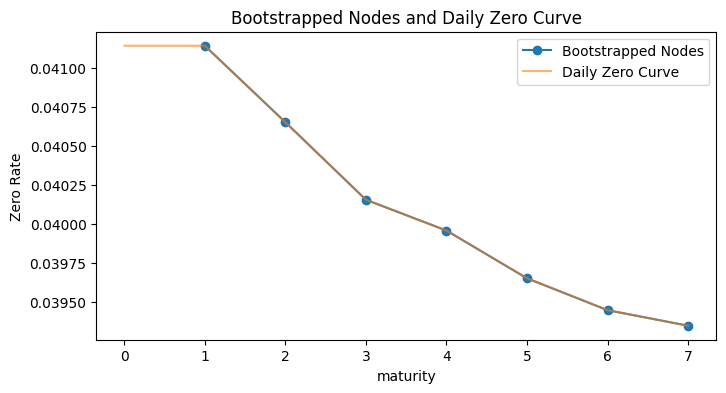

In [8]:
ax = curve_nodes_df.plot(x='maturity', y='zero_rate', marker='o', figsize=(8, 4), label='Bootstrapped Nodes')
daily_curve_df.plot(x='maturity', y='zero_rate', figsize=(8, 4), alpha=0.6, ax=ax, label='Daily Zero Curve')
ax.set_title('Bootstrapped Nodes and Daily Zero Curve')
ax.set_ylabel('Zero Rate')
plt.show()

## 4. Compute Annuity and Par Swap Rate

The annuity is the discounted sum of fixed-leg accrual weights. The par swap rate is then derived from the difference between the start and end discount factors divided by that annuity.

In [9]:
start = 0.0
tenor = 5.0
pay_frequency = 1

annuity = swap_annuity(curve_nodes, expiry=start, tenor=tenor, pay_frequency=pay_frequency)
par_rate = forward_swap_rate(curve_nodes, expiry=start, tenor=tenor, pay_frequency=pay_frequency)

pd.DataFrame([
    {'metric': 'annuity', 'value': annuity},
    {'metric': 'par_swap_rate', 'value': par_rate},
])

,metric,value
0,annuity,4.440559
1,par_swap_rate,0.040500


## 5. Value Fixed and Floating Legs

We compare a par swap and a richer-than-par fixed coupon. At par, the payer swap PV should be close to zero. If the fixed rate is above par, the payer swap should lose value and the receiver swap should gain value.

In [10]:
notional = 10_000_000.0
rich_fixed_rate = par_rate + 0.0025

fixed_leg_par = fixed_leg_pv(curve_nodes, notional, par_rate, start, tenor, pay_frequency)
fixed_leg_rich = fixed_leg_pv(curve_nodes, notional, rich_fixed_rate, start, tenor, pay_frequency)
floating_leg = floating_leg_pv(curve_nodes, notional, start, tenor)

pd.DataFrame([
    {'case': 'par fixed rate', 'fixed_leg_pv': fixed_leg_par, 'floating_leg_pv': floating_leg},
    {'case': 'rich fixed rate', 'fixed_leg_pv': fixed_leg_rich, 'floating_leg_pv': floating_leg},
])

,case,fixed_leg_pv,floating_leg_pv
0,par fixed rate,1.798426e+06,1.798426e+06
1,rich fixed rate,1.909440e+06,1.798426e+06


In [11]:
payer_par = swap_present_value(curve_nodes, notional, par_rate, start, tenor, pay_frequency, 'payer')
receiver_par = swap_present_value(curve_nodes, notional, par_rate, start, tenor, pay_frequency, 'receiver')
payer_rich = swap_present_value(curve_nodes, notional, rich_fixed_rate, start, tenor, pay_frequency, 'payer')
receiver_rich = swap_present_value(curve_nodes, notional, rich_fixed_rate, start, tenor, pay_frequency, 'receiver')

swap_values = pd.DataFrame([
    {'case': 'par fixed rate', 'payer_swap_pv': payer_par, 'receiver_swap_pv': receiver_par},
    {'case': 'rich fixed rate', 'payer_swap_pv': payer_rich, 'receiver_swap_pv': receiver_rich},
])
swap_values

,case,payer_swap_pv,receiver_swap_pv
0,par fixed rate,2.328306e-10,-2.328306e-10
1,rich fixed rate,-1.110140e+05,1.110140e+05


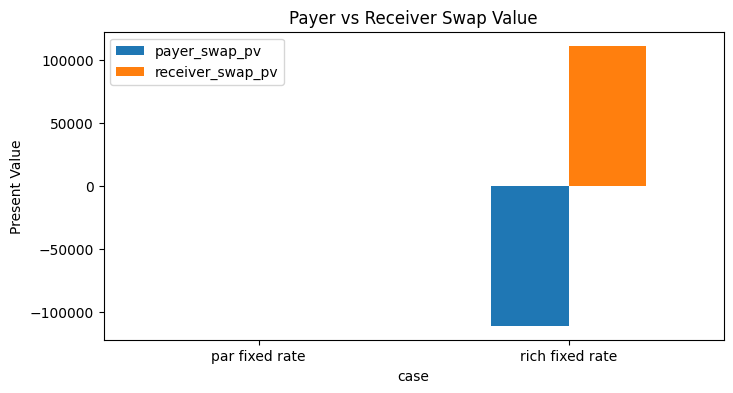

In [12]:
ax = swap_values.plot(x='case', y=['payer_swap_pv', 'receiver_swap_pv'], kind='bar', figsize=(8, 4))
ax.set_title('Payer vs Receiver Swap Value')
ax.set_ylabel('Present Value')
plt.xticks(rotation=0)
plt.show()

## 6. Interpretation

- The bootstrap turns quoted instruments into a sparse zero curve.
- Linear interpolation fills the gaps and produces a daily curve.
- The annuity summarizes fixed-leg discounting.
- The par swap rate balances fixed and floating legs.
- Once the fixed coupon is above par, the payer swap loses value and the receiver swap gains value.

This is the foundation for the later Black and SABR swaption modules.